# 数据探查：微信公众号文章 (wechat)

路径：`/home/intern_fjq_2026/data/NLP/news/wechat_20240101_20241231.jsonl`

目标：彻底理解这份新闻类 jsonl 的整体数据结构。

> 前 3 个逻辑 cell：`read_json` 加载 `df` → `df.head()` → 打印 `shape` 与 `columns`。
> 注意：该文件只有 **标题 + 摘要**，完整正文经 `S3_URL` 指向的对象存储读取，不在本 jsonl 内。


In [1]:
import pandas as pd

df = pd.read_json('/home/intern_fjq_2026/data/NLP/news/wechat_20240101_20241231.jsonl', lines=True)


In [2]:
df.head()


,NEWS_ID,NEWS_TITLE,NEWS_PUBLISH_TIME,EFFECTIVE_TIME,NEWS_ORIGIN_SOURCE,NEWS_AUTHOR,NEWS_PUBLISH_SITE,NEWS_URL,S3_URL,NEWS_SUMMARY
0,192235177,一元复始，新年让好事发生,2024-01-01 00:00:00,2024-01-01 00:00:00,上海电气风电集团,SE_windpower,上海电气风电集团,https://mp.weixin.qq.com/s?t=pages/image_detai...,/newsbody/qYn97HUvqirqL4QRXLE3RQ,一元复始，新年让好事发生
1,176568019,美畅股份新年致辞：向未来 去创造,2024-01-01 00:00:00,2024-01-01 00:00:00,美畅股份,gh_9f9740297b56,美畅股份,https://mp.weixin.qq.com/s?__biz=MzIzNzI0NzQwM...,/newsbody/oLtfJTBLgghIwkw83ojRUQ,美畅股份新年致辞：向未来 去创造
2,160468579,中国共产党甘肃省第十四届委员会第四次全体会议决议,2023-12-31 23:59:00,2024-01-01 00:00:03,读者出版传媒股份有限公司,duzhepmc,读者出版传媒股份有限公司,https://mp.weixin.qq.com/s?__biz=MzA5ODM1OTg2M...,/newsbody/tzHc21En278a7CoJBr-fow,要实施链条韧性培育锻造行动，做优做强重点产业链，推进产业基础高级化，培育先进制造业集群，强化...
3,160468581,国家主席习近平发表二〇二四年新年贺词！,2023-12-31 23:59:00,2024-01-01 00:00:03,读者出版传媒股份有限公司,duzhepmc,读者出版传媒股份有限公司,https://mp.weixin.qq.com/s?__biz=MzA5ODM1OTg2M...,/newsbody/slj8fcBf8Cv6G9AQEh5LOA,新年前夕，国家主席习近平通过中央广播电视总台和互联网，发表了二〇二四年新年贺词。东北全面振兴...
4,160468582,梁朝阳检查节日期间集团经营和安全等工作,2023-12-31 23:59:00,2024-01-01 00:00:03,读者出版传媒股份有限公司,duzhepmc,读者出版传媒股份有限公司,https://mp.weixin.qq.com/s?__biz=MzA5ODM1OTg2M...,/newsbody/pFFflBIggfWRR8RS7v6HwQ,在2024年元旦来临之际，12月31日下午，集团党委书记、董事长梁朝阳深入基层单位检查节日期...


In [3]:
print("shape:", df.shape)
print("columns:")
print(df.columns.tolist())


shape: (963967, 10)
columns:
['NEWS_ID', 'NEWS_TITLE', 'NEWS_PUBLISH_TIME', 'EFFECTIVE_TIME', 'NEWS_ORIGIN_SOURCE', 'NEWS_AUTHOR', 'NEWS_PUBLISH_SITE', 'NEWS_URL', 'S3_URL', 'NEWS_SUMMARY']


In [4]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei", "WenQuanYi Zen Hei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("DataFrame shape:", df.shape)
print("内存占用(deep): {:.1f} MB".format(df.memory_usage(deep=True).sum() / 1024**2))
time_cols = ["NEWS_PUBLISH_TIME", "EFFECTIVE_TIME"]
text_cols = ["NEWS_TITLE", "NEWS_SUMMARY"]
cat_cols  = ["NEWS_ORIGIN_SOURCE", "NEWS_AUTHOR", "NEWS_PUBLISH_SITE"]
url_cols  = ["NEWS_URL", "S3_URL"]
id_cols   = ["NEWS_ID"]

field_meaning = {
    "NEWS_ID": "新闻唯一ID",
    "NEWS_TITLE": "新闻标题",
    "NEWS_PUBLISH_TIME": "发布时间",
    "EFFECTIVE_TIME": "生效/抓取时间",
    "NEWS_ORIGIN_SOURCE": "原始来源媒体",
    "NEWS_AUTHOR": "作者",
    "NEWS_PUBLISH_SITE": "发布站点",
    "NEWS_URL": "原文链接",
    "S3_URL": "正文存储路径(S3 key)",
    "NEWS_SUMMARY": "新闻摘要",
}
pd.DataFrame({"字段含义": field_meaning}).reindex(df.columns)


DataFrame shape: (963967, 10)


内存占用(deep): 921.7 MB


,字段含义
NEWS_ID,新闻唯一ID
NEWS_TITLE,新闻标题
NEWS_PUBLISH_TIME,发布时间
EFFECTIVE_TIME,生效/抓取时间
NEWS_ORIGIN_SOURCE,原始来源媒体
NEWS_AUTHOR,作者
NEWS_PUBLISH_SITE,发布站点
NEWS_URL,原文链接
S3_URL,正文存储路径(S3 key)
NEWS_SUMMARY,新闻摘要


## 1. 字段类型 / 缺失 / 唯一值总览


In [5]:
# ============================================================
# 1. 字段类型 / 缺失 / 唯一值总览
# ============================================================
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "null": df.isna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=False),
})
overview.sort_values(["null_pct", "n_unique"], ascending=[False, False])


,dtype,non_null,null,null_pct,n_unique
NEWS_SUMMARY,object,963422,545,0.06,844049
S3_URL,object,963739,228,0.02,963740
NEWS_ID,int64,963967,0,0.00,963967
NEWS_URL,object,963967,0,0.00,963967
NEWS_TITLE,object,963967,0,0.00,861084
EFFECTIVE_TIME,datetime64[ns],963967,0,0.00,394771
NEWS_PUBLISH_TIME,datetime64[ns],963967,0,0.00,230369
NEWS_PUBLISH_SITE,object,963967,0,0.00,2750
NEWS_ORIGIN_SOURCE,object,963967,0,0.00,2696
NEWS_AUTHOR,object,963967,0,0.00,2654


## 2. 主键 / 唯一性 / 重复


In [6]:
# ============================================================
# 2. 主键 / 唯一性 / 重复
# ============================================================
print("总行数:", len(df))
print("NEWS_ID 唯一性 is_unique =", df["NEWS_ID"].is_unique, "| 唯一值数 =", df["NEWS_ID"].nunique())
print("完全重复的行数 =", int(df.duplicated().sum()))
print("去掉 NEWS_ID 后仍完全重复的记录数 =", int(df.drop(columns=["NEWS_ID"]).duplicated().sum()))
print("S3_URL 非空 = %d，唯一值 = %d，重复(正文指针复用) = %d" % (
    int(df["S3_URL"].notna().sum()), df["S3_URL"].nunique(),
    int(df["S3_URL"].dropna().duplicated().sum())))


总行数: 963967
NEWS_ID 唯一性 is_unique = True | 唯一值数 = 963967


完全重复的行数 = 0


去掉 NEWS_ID 后仍完全重复的记录数 = 0


S3_URL 非空 = 963739，唯一值 = 963739，重复(正文指针复用) = 0


## 3. 时间维度


NEWS_PUBLISH_TIME 解析失败行数: 0
发布时间范围: 2023-12-31 23:59:00 → 2024-12-31 23:58:00
发布时间去重日期数: 367

按月发布量：
2023-12        8
2024-01    84524
2024-02    65579
2024-03    84288
2024-04    81806
2024-05    83225
2024-06    77184
2024-07    85629
2024-08    82483
2024-09    79593
2024-10    76594
2024-11    78504
2024-12    84550
Freq: M, Name: NEWS_PUBLISH_TIME, dtype: int64

生效时间 - 发布时间 时差(分钟): min/中位/均值/max = 0.0 / 1.3 / 1.8 / 682.6


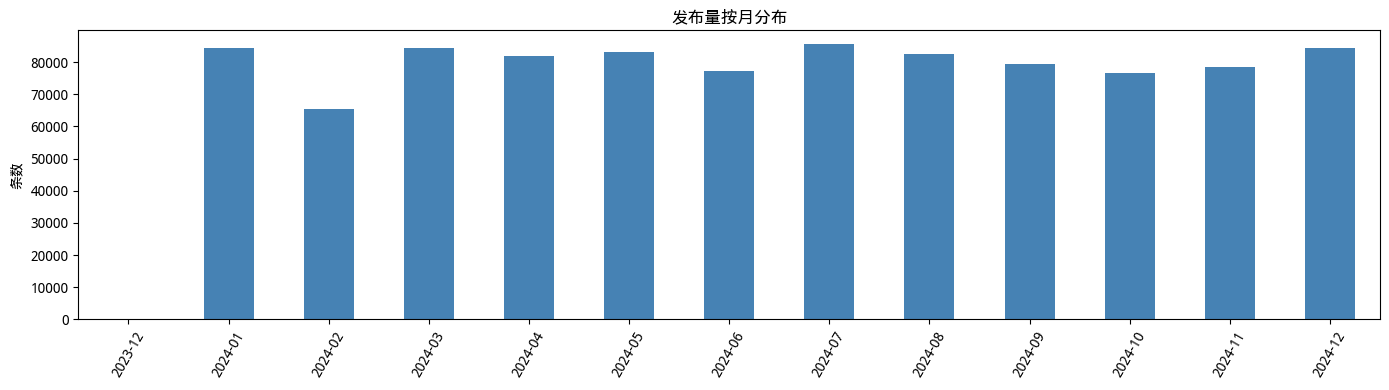

In [7]:
# ============================================================
# 3. 时间维度
# ============================================================
pub = pd.to_datetime(df["NEWS_PUBLISH_TIME"], errors="coerce")
eff = pd.to_datetime(df["EFFECTIVE_TIME"], errors="coerce")
print("NEWS_PUBLISH_TIME 解析失败行数:", int(pub.isna().sum()))
print("发布时间范围:", pub.min(), "→", pub.max())
print("发布时间去重日期数:", pub.dt.normalize().nunique())

monthly = pub.dt.to_period("M").value_counts().sort_index()
print("\n按月发布量：")
print(monthly)

lag_min = (eff - pub).dt.total_seconds() / 60
print("\n生效时间 - 发布时间 时差(分钟): min/中位/均值/max = %.1f / %.1f / %.1f / %.1f" % (
    lag_min.min(), lag_min.median(), lag_min.mean(), lag_min.max()))

plt.figure(figsize=(14, 4))
monthly.plot(kind="bar", color="steelblue")
plt.title("发布量按月分布")
plt.ylabel("条数")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


## 4. 文本字段（TITLE / SUMMARY）


NEWS_TITLE 无缺失 = True | 长度 min/中位/均值/max = 3 / 22.0 / 23.6 / 64



NEWS_SUMMARY 非空 963422 / 963967，缺失 545 (0.06%)


NEWS_SUMMARY(非空) 长度：min/中位/均值/max = 0 / 89.0 / 82.3 / 868
SUMMARY 长度分位数：
0.00      0.0
0.25     66.0
0.50     89.0
0.75    105.0
0.90    114.0
0.99    120.0
1.00    868.0
Name: NEWS_SUMMARY, dtype: float64



标题去重: TITLE 唯一值 861084 / 行数 963967，重复标题行数 = 102883


摘要去重: SUMMARY 唯一值(非空) 844048 / 非空 963422，重复摘要条数 = 119374


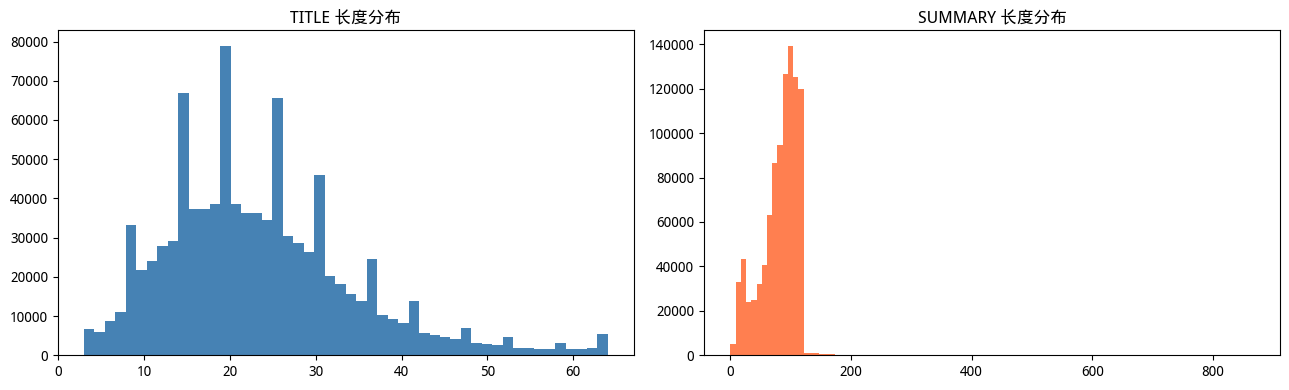


--- 最长摘要样本 ---
index=309804, 长度=868, 标题=低空经济后续行情怎么看？
讨论集中在低空经济的巨大潜力及其向实际应用的转化可能性上，预示着一个庞大的新兴产业即将成形。尽管市场对此有所分歧，公共认知和投资者态度不一，业内普遍保持乐观，强调即便解决方案尚未成熟，也需积极参与。此外，尽管资本对该领域的理解还需时日，尤其对于初期参与者而言充满挑战，但预期未来随着更多信息的披露，投资者将对该领域有更深刻的见解。政府发布的低空政策正式标志了这一领域的新纪元，设定目标至2027年实现新型航空装备的商业化应用，并计划在2030年之前达到万亿元的市场规模。此政策突出了技术和产业链供应链的发展，并明确了基础设施建设和生态融合的任务，还提出了国际化战略，展现了政府对该领域的全力支持和期待。低空经济产业链涉及从整机制造到上游原材料和关键零部件等多个方面。面对该领域特有的技术要求，产业链每个环节面临着不同机遇和挑战，特别是电动机和控制器的技术进步可能导致强者恒强的局面，而电池技术的进步则可能让技术先进者脱颖而出。轻量化材料的使用更是成为提升产品性能的关键。此外，特别提到了低空基础设施建设成为新的市场热点，各地正积极探索适合自己国情的标准和模式，预计未来几年将为相关设计公司带来巨大的增长潜力。政府持续加大对高价值项目的投入，以推动经济的发展，低空基建作为新热点受到广泛关注，特别是川渝和海南等地，因其特殊的地理条件显示出巨大的市场潜力。低空交通和旅游业的发展被视为新的经济增长点，同时也增加了无人机在各种监测和维护任务中的应用。专家分析指出，随着政府对无人机行业的支持力度加大，特别是在2027年预计无人机将成为主要运输方式的基础上，工业级无人机市场将迎来重大发展机遇。特别推荐华社集团，该企业在基建设计运营方面表现出色，特别是在低空空管系统方面的潜力，已经与南航等建立合作，涵盖了物流、通航等领域，并已在实施三证合一政策，有望加速订单落地。总而言之，低空经济及相关服务领域展示了巨大的发展潜力和商业机会，值得关注和投资。投资者应专注于具有成长潜力、估值合理的公司，尤其是在无人机及其供应链领域，并抓住低估值投资的机会。

--- 最短摘要样本 ---
index=457310, 长度=0, 标题=锂电-固态电池近期调研反馈
''


In [8]:
# ============================================================
# 4. 文本字段长度 / 重复 / 样本
# ============================================================
title_len = df["NEWS_TITLE"].str.len()
print("NEWS_TITLE 无缺失 =", bool(df["NEWS_TITLE"].notna().all()),
      "| 长度 min/中位/均值/max = %d / %.1f / %.1f / %d" % (
          title_len.min(), title_len.median(), title_len.mean(), title_len.max()))

summary = df["NEWS_SUMMARY"].dropna()
print("\nNEWS_SUMMARY 非空 %d / %d，缺失 %d (%.2f%%)" % (
    len(summary), len(df),
    int(df["NEWS_SUMMARY"].isna().sum()), df["NEWS_SUMMARY"].isna().mean() * 100))
slen = summary.str.len()
print("NEWS_SUMMARY(非空) 长度：min/中位/均值/max = %d / %.1f / %.1f / %d" % (
    slen.min(), slen.median(), slen.mean(), slen.max()))
print("SUMMARY 长度分位数：")
print(slen.quantile([0.0, 0.25, 0.5, 0.75, 0.9, 0.99, 1.0]))

print("\n标题去重: TITLE 唯一值 %d / 行数 %d，重复标题行数 = %d" % (
    df["NEWS_TITLE"].nunique(), len(df), int(df["NEWS_TITLE"].duplicated().sum())))
print("摘要去重: SUMMARY 唯一值(非空) %d / 非空 %d，重复摘要条数 = %d" % (
    summary.nunique(), len(summary), int(summary.duplicated().sum())))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(title_len, bins=50, color="steelblue")
axes[0].set_title("TITLE 长度分布")
axes[1].hist(slen, bins=100, color="coral")
axes[1].set_title("SUMMARY 长度分布")
plt.tight_layout()
plt.show()

print("\n--- 最长摘要样本 ---")
i = slen.idxmax()
print("index=%d, 长度=%d, 标题=%s" % (i, slen[i], df.loc[i, "NEWS_TITLE"]))
print(df.loc[i, "NEWS_SUMMARY"][:1500])
print("\n--- 最短摘要样本 ---")
j = slen.idxmin()
print("index=%d, 长度=%d, 标题=%s" % (j, slen[j], df.loc[j, "NEWS_TITLE"]))
print(repr(df.loc[j, "NEWS_SUMMARY"]))


## 5. 分类字段（来源媒体 / 作者 / 站点）


NEWS_ORIGIN_SOURCE  唯一值数=2696


券商中国        12599
新闻晨报         9745
中国证券报        8918
每日经济新闻       8076
澎湃新闻         8033
上海证券报        7683
深圳商报         7166
第一财经         6889
界面新闻         6597
21世纪经济报道     6153
知道News       6112
新晚报          6001
大河报          5901
长安街知事        5007
华夏时报         4892
新华社          4833
人民网          4527
虎嗅APP        4041
国际金融报        3878
36氪          3755



NEWS_AUTHOR  唯一值数=2654


quanshangcn        12599
shxwcb              9745
xhszzb              8920
nbdnews             8076
thepapernews        8033
shzqbwx             7683
szed2018            7166
cbn-yicai           6889
wowjiemian          6597
jjbd21              6153
xjb-jingshier       6112
xinwanbao           6001
dahebao19950801     5901
capitalnews         5000
chinatimes          4892
xinhuashefabu1      4833
people_rmw          4527
huxiu_com           4041
gjjrb777            3878
wow36kr             3755

NEWS_PUBLISH_SITE  唯一值数=2750
券商中国        12599
新闻晨报         9745
中国证券报        8920
每日经济新闻       8076
澎湃新闻         8033
上海证券报        7683
深圳商报         7166
第一财经         6889
界面新闻         6597
21世纪经济报道     6153
知道News       6112
新晚报          6001
大河报          5901
长安街知事        5007
华夏时报         4892
新华社          4833
人民网          4527
虎嗅APP        4041
国际金融报        3878
36氪          3755



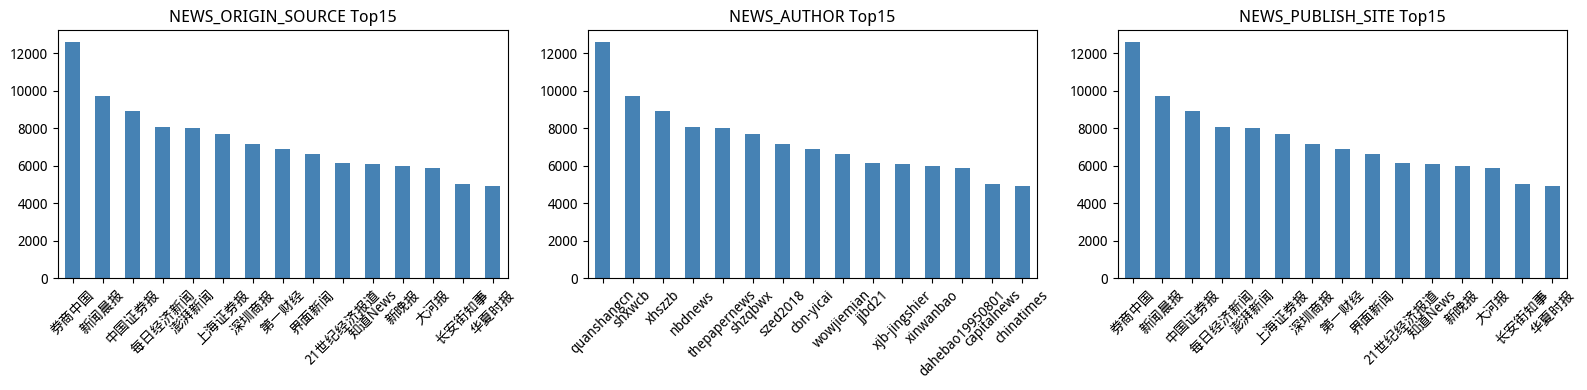

In [9]:
# ============================================================
# 5. 分类字段取值分布
# ============================================================
for c in cat_cols:
    print("=" * 70)
    print("%s  唯一值数=%d" % (c, df[c].nunique(dropna=True)))
    print(df[c].value_counts(dropna=False).head(20).to_string())
    print()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, c in enumerate(cat_cols):
    df[c].value_counts(dropna=False).head(15).plot(kind="bar", ax=axes[i], color="steelblue")
    axes[i].set_title(c + " Top15")
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 6. 链接与正文存储指针


In [10]:
# ============================================================
# 6. 链接与正文存储指针
# ============================================================
dom = df["NEWS_URL"].dropna().str.extract(r"https?://([^/]+)", expand=False)
print("NEWS_URL 域名 Top20：")
print(dom.value_counts().head(20).to_string())

print("\nS3_URL 前缀样例(前 10)：")
for s in df["S3_URL"].dropna().unique()[:10]:
    print("  ", s)
print("S3_URL 去重唯一值 =", df["S3_URL"].nunique(),
      "| 复用 (重复) 的指针数 =", int(df["S3_URL"].dropna().duplicated().sum()))


NEWS_URL 域名 Top20：
mp.weixin.qq.com    963967

S3_URL 前缀样例(前 10)：


   /newsbody/qYn97HUvqirqL4QRXLE3RQ
   /newsbody/oLtfJTBLgghIwkw83ojRUQ
   /newsbody/tzHc21En278a7CoJBr-fow
   /newsbody/slj8fcBf8Cv6G9AQEh5LOA
   /newsbody/pFFflBIggfWRR8RS7v6HwQ
   /newsbody/okEOkw0aqfU-y1_BtjFz0w
   /newsbody/5AnD0MprFuDJy5mdssTwZg
   /newsbody/aOf7CluKiYaA5wI6VkEu6g
   /newsbody/ISNVirjWgTPmwn_D51E9JQ
   /newsbody/QpubzB5r2A6pATLwTtAm4A


S3_URL 去重唯一值 = 963739 | 复用 (重复) 的指针数 = 0


## 7. 来源媒体 ↔ 站点 / 作者 关系


In [11]:
# ============================================================
# 7. 来源媒体 ↔ 站点 / 作者 关系
# ============================================================
src_sites = df.groupby("NEWS_ORIGIN_SOURCE")["NEWS_PUBLISH_SITE"].nunique().sort_values(ascending=False)
print("每个来源媒体对应发布站点数 Top20：")
print(src_sites.head(20).to_string())

site_authors = df.groupby("NEWS_PUBLISH_SITE")["NEWS_AUTHOR"].nunique().sort_values(ascending=False)
print("\n每个站点作者数 Top20：")
print(site_authors.head(20).to_string())


每个来源媒体对应发布站点数 Top20：
NEWS_ORIGIN_SOURCE
益研究 价值学堂        3
智堡投研            3
晓鹏的宏观图表         3
国投证券研究          3
马江博说趋势          3
经理人产业管理         3
啟灵投研            3
兵器步             3
安信证券资管订阅号       3
白猫投诉            3
成竹海外            3
海通宏观研究          2
四川长虹            2
天华CANMAX        2
金融监管研究院         2
大道交易            2
德科未来城市          2
天娱数科CLUB        2
WitsView睿智显示    2
选股通订阅号          2



每个站点作者数 Top20：
NEWS_PUBLISH_SITE
日中资本市场         2
辰安科技           2
中国国际期货         2
孟岩             2
laoduo         2
还是胡扯的Matias    2
陈兴宏观研究         2
股市早八点          2
富祥药业           2
远方青木           2
董秘学苑           2
EarlETF        2
晓鹏的宏观图表        2
ZEALER         2
红杉汇            2
叶秋的投资哲学        2
浙商期货有限公司       2
XYSTRATEGY     2
马江博说趋势         2
白猫投诉           2


## 8. 原始数据抽样查看


In [12]:
# ============================================================
# 8. 原始数据抽样查看
# ============================================================
sample = df.sample(n=3, random_state=42)
for i, (idx, row) in enumerate(sample.iterrows(), 1):
    print("=" * 80)
    print("样本 %d / 3   (原始 index=%d, NEWS_ID=%s)" % (i, idx, row["NEWS_ID"]))
    print("-" * 80)
    for col in df.columns:
        val = row[col]
        if isinstance(val, str) and len(val) > 300:
            val = val[:300] + "  ......[截断]"
        print("%-22s : %s" % (col, val))
    print()


样本 1 / 3   (原始 index=408228, NEWS_ID=173349915)
--------------------------------------------------------------------------------
NEWS_ID                : 173349915
NEWS_TITLE             : 吨钢利润空间回落，短期废钢或将稳中偏弱调整
NEWS_PUBLISH_TIME      : 2024-06-04 18:11:00
EFFECTIVE_TIME         : 2024-06-04 18:12:12
NEWS_ORIGIN_SOURCE     : 我的钢铁网
NEWS_AUTHOR            : Mysteel-shgl
NEWS_PUBLISH_SITE      : 我的钢铁网
NEWS_URL               : https://mp.weixin.qq.com/s?__biz=MjM5NjI5OTcwMw==&mid=2651082662&idx=4&sn=c3d190a06c752eef900a40c0bf6c512d&chksm=bc139d8951e4fee669425977ce7d6289cc078238a0b0d6907b9e002d441fa2f243fda30f4f14&scene=0&xtrack=1
S3_URL                 : /newsbody/PSV-okc9I0DFkP24elPnYQ
NEWS_SUMMARY           : 01废钢供应稍强于需求 短期价格或稳中偏弱运行本周为六月第一周，市场逐渐显现淡季效应，终端需求出现回落，成品材成交量表现较差，钢厂吨钢利润和综合利润均出现下降，部分甚至处于盈亏边际，对废钢需求量表现一般。

样本 2 / 3   (原始 index=662751, NEWS_ID=182821950)
--------------------------------------------------------------------------------
NEWS_ID                : 182821950
NEWS_TITLE      

## 9. 结论摘要（自动汇总）


In [13]:
# ============================================================
# 9. 结论摘要（自动汇总）
# ============================================================
pub_dt = pd.to_datetime(df["NEWS_PUBLISH_TIME"], errors="coerce")
lines = []
lines.append("文件: /home/intern_fjq_2026/data/NLP/news/wechat_20240101_20241231.jsonl")
lines.append("总记录数: %d 行 × %d 列" % df.shape)
lines.append("发布时间范围: %s ~ %s (去重日期 %d 天)" % (
    pub_dt.min(), pub_dt.max(), pub_dt.dt.normalize().nunique()))
lines.append("NEWS_ID 唯一: %s；完全重复行: %d；去掉 ID 后重复: %d" % (
    df["NEWS_ID"].is_unique, int(df.duplicated().sum()),
    int(df.drop(columns=["NEWS_ID"]).duplicated().sum())))
lines.append("发布站点 %d 个 / 来源媒体 %d 个 / 作者 %d 个" % (
    df["NEWS_PUBLISH_SITE"].nunique(), df["NEWS_ORIGIN_SOURCE"].nunique(),
    df["NEWS_AUTHOR"].nunique()))
lines.append("摘要(NEWS_SUMMARY)缺失率: %.2f%%；标题缺失率: %.2f%%；标题重复数: %d" % (
    df["NEWS_SUMMARY"].isna().mean()*100, df["NEWS_TITLE"].isna().mean()*100,
    int(df["NEWS_TITLE"].duplicated().sum())))
lines.append("S3_URL(正文指针) 非空 %d，唯一 %d，复用 %d" % (
    int(df["S3_URL"].notna().sum()), df["S3_URL"].nunique(),
    int(df["S3_URL"].dropna().duplicated().sum())))
print("\n".join(lines))


文件: /home/intern_fjq_2026/data/NLP/news/wechat_20240101_20241231.jsonl
总记录数: 963967 行 × 10 列
发布时间范围: 2023-12-31 23:59:00 ~ 2024-12-31 23:58:00 (去重日期 367 天)
NEWS_ID 唯一: True；完全重复行: 0；去掉 ID 后重复: 0
发布站点 2750 个 / 来源媒体 2696 个 / 作者 2654 个
摘要(NEWS_SUMMARY)缺失率: 0.06%；标题缺失率: 0.00%；标题重复数: 102883
S3_URL(正文指针) 非空 963739，唯一 963739，复用 0
